# Patrones Invisibles: Información, Incertidumbre y Movilidad Urbana

Diego Durán, Laura Gómez, Rosario Lozano, Juliana Reyes

## 0\. Carga y preprocesamiento de los datos

El dataset completo (~1.4M registros) no se procesa completo en cada iteración. Se toma una muestra aleatoria reproducible de **40 000 viajes** (`random_state=42`), suficiente para estimar distribuciones de probabilidad estables sin costo computacional alto.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import entropy as shannon_entropy
from scipy.special import logsumexp

PATH_CSV = "train.csv"

def cargar_datos(path_csv, muestra=40000, seed=42):
    """Carga el dataset y toma una muestra aleatoria reproducible."""
    df = pd.read_csv(path_csv)
    if len(df) > muestra:
        df = df.sample(n=muestra, random_state=seed).reset_index(drop=True)
    df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
    return df

df = cargar_datos(PATH_CSV)
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,2016-06-08 07:53:39,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,2016-04-03 13:11:58,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,2016-06-05 02:59:27,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2016-05-05 17:32:54,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,2016-05-12 19:06:25,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


Antes de calcular cualquier métrica se filtran los registros inválidos o atípicos, ya que distorsionan la distribución de probabilidad usada para la entropía:

| Filtro | Regla aplicada | Justificación |
|---|---|---|
| Coordenadas fuera de NYC | lat ∈ [40.5, 40.9], lon ∈ [-74.05, -73.7] | Coordenadas erróneas (p. ej. (0,0)) crean "zonas fantasma" que inflan la entropía. |
| `passenger_count = 0` | Se excluye | No representa un viaje real. |
| `trip_duration` extremo | Se conserva solo 60s – 4h | Duraciones de 1s o de varios días son errores de registro. |
| Duplicados | `drop_duplicates()` | Evita sobre-representar un mismo viaje. |

Se reporta cuántos registros se eliminaron y qué porcentaje representan, para que el filtrado sea auditable.

In [2]:
def limpiar_datos(df):
    """
    Filtra registros inválidos o atípicos antes de cualquier cálculo:
    - Coordenadas fuera del bounding box de NYC.
    - passenger_count igual a 0.
    - trip_duration demasiado corto (<60s) o demasiado largo (>4h).
    - Duplicados exactos.
    """
    n_inicial = len(df)

    lat_min, lat_max = 40.5, 40.9
    lon_min, lon_max = -74.05, -73.7
    df = df[
        df["pickup_latitude"].between(lat_min, lat_max)
        & df["pickup_longitude"].between(lon_min, lon_max)
        & df["dropoff_latitude"].between(lat_min, lat_max)
        & df["dropoff_longitude"].between(lon_min, lon_max)
    ]

    df = df[df["passenger_count"] > 0]
    df = df[df["trip_duration"].between(60, 4 * 3600)]
    df = df.drop_duplicates()

    n_final = len(df)
    print(
        f"[limpieza] {n_inicial} -> {n_final} registros "
        f"({n_inicial - n_final} eliminados, "
        f"{(n_inicial - n_final) / n_inicial:.1%})"
    )
    return df.reset_index(drop=True)

df = limpiar_datos(df)

[limpieza] 40000 -> 39541 registros (459 eliminados, 1.1%)


## Zonificación

Se construye una zona geográfica simple mediante un **grid de 10×10** sobre `pickup_latitude` y `pickup_longitude`, combinando el bin de latitud y el de longitud en un identificador único de zona. Este grid es la base sobre la que  se mide la dispersión/concentración de la demanda.

In [3]:
def asignar_zona(df, n_bins=10):
    """
    Crea una zona simple mediante un grid geográfico (n_bins x n_bins)
    sobre las coordenadas de recogida.
    """
    lat_bins = pd.cut(df["pickup_latitude"], bins=n_bins, labels=False)
    lon_bins = pd.cut(df["pickup_longitude"], bins=n_bins, labels=False)
    df["zona"] = lat_bins.astype(str) + "_" + lon_bins.astype(str)
    return df

df = asignar_zona(df, n_bins=10)
df["zona"].nunique()

59

## Entropía de Shannon

Para un conjunto de viajes, se calcula la frecuencia relativa (probabilidad empírica) de cada zona y se aplica la fórmula de Shannon en base 2 (bits):

$$H(X) = - \sum_x p(x) \cdot \log_2 p(x)$$

- **Entropía baja** → la demanda está concentrada en pocas zonas (más predecible).
- **Entropía alta** → la demanda está dispersa entre muchas zonas (menos predecible).

In [4]:
def entropia_de_distribucion(serie_categorica, base=2):
    """
    Calcula la entropía de Shannon (en bits, base=2) de una serie categórica,
    a partir de sus frecuencias relativas (probabilidades empíricas).
    """
    probs = serie_categorica.value_counts(normalize=True).values
    entropia = shannon_entropy(probs, base=base)
    print(f"Entropía: {entropia:.4f} bits")
    return entropia

### Entropía por hora del día

Se agrupan los viajes por hora (0-23) y se calcula la entropía de la distribución de zonas dentro de cada hora, para ver en qué momentos del día la demanda es más o menos predecible espacialmente.

In [5]:
def entropia_por_hora(df):
    df["hora"] = df["pickup_datetime"].dt.hour
    resultados = {}
    for hora, grupo in df.groupby("hora"):
        resultados[hora] = entropia_de_distribucion(grupo["zona"])
    return pd.Series(resultados).sort_index().rename("entropia_bits")

h_por_hora = entropia_por_hora(df)
h_por_hora.round(3)

Entropía: 3.2416 bits
Entropía: 3.0306 bits
Entropía: 2.9430 bits
Entropía: 2.9369 bits
Entropía: 3.1572 bits
Entropía: 3.4341 bits
Entropía: 3.4085 bits
Entropía: 3.2904 bits
Entropía: 3.2127 bits
Entropía: 3.1136 bits
Entropía: 3.0872 bits
Entropía: 3.0476 bits
Entropía: 3.0524 bits
Entropía: 3.0939 bits
Entropía: 3.0985 bits
Entropía: 3.1469 bits
Entropía: 3.1754 bits
Entropía: 3.0975 bits
Entropía: 2.9714 bits
Entropía: 3.0522 bits
Entropía: 3.0527 bits
Entropía: 3.0340 bits
Entropía: 3.1136 bits
Entropía: 3.1548 bits


0     3.242
1     3.031
2     2.943
3     2.937
4     3.157
5     3.434
6     3.408
7     3.290
8     3.213
9     3.114
10    3.087
11    3.048
12    3.052
13    3.094
14    3.099
15    3.147
16    3.175
17    3.098
18    2.971
19    3.052
20    3.053
21    3.034
22    3.114
23    3.155
Name: entropia_bits, dtype: float64

<Axes: title={'center': 'Entropía de la demanda por zona, según hora del día'}>

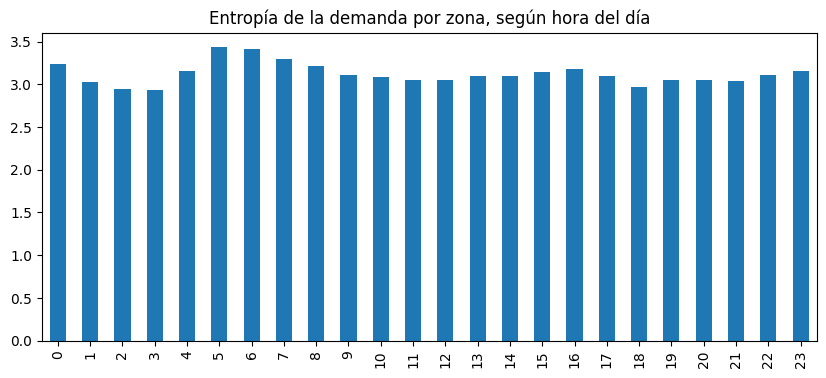

In [6]:
h_por_hora.plot(kind="bar", figsize=(10, 4), title="Entropía de la demanda por zona, según hora del día")

### Comparación pico vs. valle

Se comparan dos subconjuntos (7-9h y 17-19h vs. el resto) para ver cuál tiene mayor concentración geográfica de la demanda.

In [7]:
def entropia_pico_vs_valle(df, horas_pico=(7, 8, 9, 17, 18, 19)):
    df["hora"] = df["pickup_datetime"].dt.hour
    pico = df[df["hora"].isin(horas_pico)]
    valle = df[~df["hora"].isin(horas_pico)]
    h_pico = entropia_de_distribucion(pico["zona"])
    h_valle = entropia_de_distribucion(valle["zona"])
    return h_pico, h_valle

h_pico, h_valle = entropia_pico_vs_valle(df)
print(f"Entropía en horario pico : {h_pico:.3f} bits")
print(f"Entropía en horario valle: {h_valle:.3f} bits")

if h_pico < h_valle:
    print("\nInterpretación: la demanda está más CONCENTRADA en pocas zonas durante horario pico (menor entropía) que en horario valle.")
else:
    print("\nInterpretación: la demanda está más DISPERSA entre zonas durante horario pico (mayor entropía) que en horario valle.")

Entropía: 3.1386 bits
Entropía: 3.1830 bits
Entropía en horario pico : 3.139 bits
Entropía en horario valle: 3.183 bits

Interpretación: la demanda está más CONCENTRADA en pocas zonas durante horario pico (menor entropía) que en horario valle.


## Entropía cruzada y divergencia KL: Día laboral vs fin de semana

Se comparan las distribuciones de demanda por zona en **día laboral (lunes-viernes)** frente a **fin de semana (sábado-domingo)**. Para comparar dos distribuciones de probabilidad que no necesariamente comparten el mismo soporte (pueden existir zonas con viajes solo uno de los dos contextos), primero se alinean sobre el conjunto unión de zonas, rellenando con una probabilidad mínima $\epsilon$ las zonas ausentes y normalizando, para evitar $\log(0)$.

$H(p, q) = -\sum_x p(x) \cdot \log_2 q(x) \qquad
D_{KL}(p \| q) = \sum_x p(x) \cdot \log_2 \frac{p(x)}{q(x)}$

- $H(p,q)$ (entropía cruzada) mide cuántos bits se necesitarían, en promedio, para codificar la distribución real $p$ usando un código óptimo diseñado para $q$.
- $D_{KL}(p\|q)$ mide cuánta "sorpresa" adicional genera asumir que la demanda del fin de semana sigue el mismo patrón que la de un día laboral (o viceversa). Es siempre $\geq 0$, y $=0$ solo si $p=q$.

In [8]:
def alinear_distribuciones(serie_p, serie_q, epsilon=1e-6):
    """
    Convierte dos series categóricas en distribuciones de probabilidad
    alineadas sobre el mismo soporte (unión de categorías), rellenando
    con epsilon las categorías ausentes en alguna de las dos y renormalizando.
    """
    p_counts = serie_p.value_counts(normalize=True)
    q_counts = serie_q.value_counts(normalize=True)
    soporte = sorted(set(p_counts.index) | set(q_counts.index))

    p = np.array([p_counts.get(z, 0.0) for z in soporte]) + epsilon
    q = np.array([q_counts.get(z, 0.0) for z in soporte]) + epsilon
    p = p / p.sum()
    q = q / q.sum()
    return p, q, soporte


def entropia_cruzada(p, q, base=2):
    """H(p, q) = -sum p(x) * log_base q(x)"""
    return -np.sum(p * (np.log(q) / np.log(base)))


def kl_divergencia(p, q, base=2):
    """D_KL(p || q) = sum p(x) * log_base(p(x)/q(x))"""
    return np.sum(p * (np.log(p / q) / np.log(base)))


df["dia_semana"] = df["pickup_datetime"].dt.dayofweek  # 0=lunes ... 6=domingo
laboral = df[df["dia_semana"] < 5]
finde = df[df["dia_semana"] >= 5]

p_laboral, q_finde, soporte = alinear_distribuciones(laboral["zona"], finde["zona"])

h_cruzada = entropia_cruzada(p_laboral, q_finde)
kl_lab_finde = kl_divergencia(p_laboral, q_finde)
kl_finde_lab = kl_divergencia(q_finde, p_laboral)
h_laboral_propia = shannon_entropy(p_laboral, base=2)

print(f"Entropía propia de la distribución laboral : {h_laboral_propia:.4f} bits")
print(f"Entropía cruzada H(laboral, finde)          : {h_cruzada:.4f} bits")
print(f"D_KL(laboral || finde)                      : {kl_lab_finde:.4f} bits")
print(f"D_KL(finde || laboral)                      : {kl_finde_lab:.4f} bits")

costo_extra = h_cruzada - h_laboral_propia
print(f"Costo extra de codificar fines de semana con patrón laboral: {costo_extra:.4f} bits")

Entropía propia de la distribución laboral : 3.1406 bits
Entropía cruzada H(laboral, finde)          : 3.1764 bits
D_KL(laboral || finde)                      : 0.0358 bits
D_KL(finde || laboral)                      : 0.0386 bits
Costo extra de codificar fines de semana con patrón laboral: 0.0358 bits


Interpretación: asumir el patrón del fin de semana para operar en día laboral cuesta 0\.0358 bits adicionales de codificación \(D\_KL=0\.0358\)\. Los dos contextos son relativamente parecidos, lo que no justifica una estrategia de posicionamiento de flota diferenciada entre semana y fin de semana\.

## Entropía condicional e información mútua

La entropía condicional $H(\text{Zona} \mid \text{Hora})$ es el promedio ponderado (por $p(\text{hora})$) de la entropía de la zona dentro de cada hora, ya calculada en `entropia_por_hora`. La información mutua mide cuántos bits de incertidumbre sobre la zona se eliminan al conocer la hora del día:

$H(\text{Zona}\mid\text{Hora}) = \sum_h p(h)\, H(\text{Zona}\mid\text{Hora}=h)
\qquad
I(\text{Zona};\text{Hora}) = H(\text{Zona}) - H(\text{Zona}\mid\text{Hora})$

In [9]:
def entropia_condicional_y_mi(df, h_por_hora):
    """
    Calcula H(Zona|Hora) como el promedio ponderado de la entropía de zona
    dentro de cada hora, y la información mutua I(Zona;Hora) = H(Zona) - H(Zona|Hora).
    """
    p_hora = df["hora"].value_counts(normalize=True).sort_index()
    h_condicional = float((p_hora * h_por_hora.reindex(p_hora.index)).sum())
    h_zona_total = shannon_entropy(df["zona"].value_counts(normalize=True), base=2)
    mi = h_zona_total - h_condicional
    return h_zona_total, h_condicional, mi


h_zona_total, h_zona_dado_hora, mi_hora_zona = entropia_condicional_y_mi(df, h_por_hora)

print(f"H(Zona)               : {h_zona_total:.4f} bits")
print(f"H(Zona | Hora)         : {h_zona_dado_hora:.4f} bits")
print(f"I(Zona ; Hora)         : {mi_hora_zona:.4f} bits")
print(f"Reducción relativa de incertidumbre al conocer la hora: {mi_hora_zona / h_zona_total:.1%}")

H(Zona)               : 3.1746 bits
H(Zona | Hora)         : 3.1076 bits
I(Zona ; Hora)         : 0.0670 bits
Reducción relativa de incertidumbre al conocer la hora: 2.1%


Interpretación: conocer la hora del día reduce en 2\.1% la incertidumbre sobre en qué zona ocurrirá la próxima recogida\. Esto es una señal débil para UrbanMove: programar el reposicionamiento de flota por franja horaria aporta poco por sí sola y debe combinarse con otras variables \(p\. ej\. día de la semana\)\.

## Uso de log\-sum\-exp

Al trabajar con log-probabilidades muy negativas (zonas de muy baja frecuencia, o las log-verosimilitudes por componente en la mezcla gaussiana del Rol 3), calcular $\sum_x p(x)$ exponenciando directamente cada $\log p(x)$ puede producir `exp` de un número muy negativo se redondea a 0.0. El truco log-sum-exp evita esto:

$\text{logsumexp}(\mathbf{z}) = \log \sum_i e^{z_i}
= m + \log \sum_i e^{z_i - m}, \qquad m = \max_i z_i$

restar el máximo antes de exponenciar mantiene los números en un rango representable.

In [10]:
def logsumexp_ingenuo(log_probs):
    """Versión NO estable: exponencia directamente cada log-probabilidad."""
    return np.log(np.sum(np.exp(log_probs)))


def logsumexp_estable(log_probs):
    """Versión estable: resta el máximo antes de exponenciar (truco log-sum-exp)."""
    m = np.max(log_probs)
    return m + np.log(np.sum(np.exp(log_probs - m)))


# Log-probabilidades por zona a partir de la distribución empírica observada
probs_zona = df["zona"].value_counts(normalize=True).values
log_probs_zona = np.log(probs_zona)

# Caso de estrés: log-probabilidades muy negativas, como las log-verosimilitudes
# por componente que produce un modelo de mezcla gaussiana (puente con el Rol 3)
log_probs_extremas = log_probs_zona - 1000  # simula log-verosimilitudes muy negativas

print("--- Caso normal (distribución de zonas) ---")
print(f"logsumexp ingenuo  : {logsumexp_ingenuo(log_probs_zona):.6f}")
print(f"logsumexp estable  : {logsumexp_estable(log_probs_zona):.6f}")
print(f"scipy.special.logsumexp de referencia: {logsumexp(log_probs_zona):.6f}")

print("\n--- Caso extremo (log-probabilidades muy negativas) ---")
with np.errstate(divide="ignore"):
    resultado_ingenuo = logsumexp_ingenuo(log_probs_extremas)
resultado_estable = logsumexp_estable(log_probs_extremas)
print(f"logsumexp ingenuo  : {resultado_ingenuo}  {'<- underflow (-inf)' if not np.isfinite(resultado_ingenuo) else ''}")
print(f"logsumexp estable  : {resultado_estable:.6f}")

--- Caso normal (distribución de zonas) ---
logsumexp ingenuo  : -0.000000
logsumexp estable  : 0.000000
scipy.special.logsumexp de referencia: 0.000000

--- Caso extremo (log-probabilidades muy negativas) ---
logsumexp ingenuo  : -inf  <- underflow (-inf)
logsumexp estable  : -1000.000000


Con las probabilidades reales de las 59 zonas, ambas versiones coinciden \(≈ 0\), por lo que el truco no es necesario en ese rango\. Al desplazar las log\-probabilidades 1000 unidades hacia abajo, la versión ingenua produce \-inf por underflow numérico \(exp\(\-1000\) = 0\.0\), mientras que la estable recupera el valor exacto de \-1000\. Este es el problema que tiene el Rol 3, ya que en el E\-step del EM, las verosimilitudes por componente gaussiana pueden ser extremadamente pequeñas, y sin log\-sum\-exp las responsabilidades se calcularían como 0/0\.

## Desigualdad de Jensen

El logaritmo es una función **cóncava**, por lo que la desigualdad de Jensen garantiza:

$\mathbb{E}[\log X] \leq \log(\mathbb{E}[X])$

Se verifica numéricamente sobre `trip_duration`, una variable con distribución muy asimétrica (muchos viajes cortos, pocos viajes muy largos).

In [11]:
log_duracion_esperado = np.mean(np.log(df["trip_duration"]))
log_de_la_media = np.log(df["trip_duration"].mean())
brecha_jensen = log_de_la_media - log_duracion_esperado

media_geometrica = np.exp(log_duracion_esperado)
media_aritmetica = df["trip_duration"].mean()

print(f"E[log(duración)]        : {log_duracion_esperado:.4f}")
print(f"log(E[duración])        : {log_de_la_media:.4f}")
print(f"Brecha de Jensen         : {brecha_jensen:.4f} (siempre >= 0, confirma la desigualdad)")
print(f"\nMedia aritmética de duración : {media_aritmetica:.1f} s ({media_aritmetica/60:.1f} min)")
print(f"Media geométrica de duración : {media_geometrica:.1f} s ({media_geometrica/60:.1f} min)")

E[log(duración)]        : 6.4772
log(E[duración])        : 6.7329
Brecha de Jensen         : 0.2557 (siempre >= 0, confirma la desigualdad)

Media aritmética de duración : 839.6 s (14.0 min)
Media geométrica de duración : 650.2 s (10.8 min)


Interpretación: la brecha de Jensen confirma que la distribución de duración está sesgada a la derecha \(pocos viajes muy largos inflan la media aritmética\)\. La media geométrica \(10\.8 min\) es un mejor estimador del viaje 'típico' que la media aritmética \(14\.0 min\)\. Usar la media aritmética para fijar tiempos de espera esperados o tarifas base sobreestima sistemáticamente la experiencia del pasajero mediano\.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [13]:
def distancia_haversine_km(lat1, lon1, lat2, lon2):
    """
    Distancia en línea recta (km) entre dos coordenadas geográficas,
    usando la fórmula de Haversine. Se usa para caracterizar cada viaje
    con una variable de distancia, independiente de trip_duration.
    """
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


df["distancia_km"] = distancia_haversine_km(
    df["pickup_latitude"], df["pickup_longitude"],
    df["dropoff_latitude"], df["dropoff_longitude"],
)
df["distancia_km"].describe()

count    39541.000000
mean         3.400582
std          3.791471
min          0.000000
25%          1.245089
50%          2.090228
75%          3.863887
max         28.532868
Name: distancia_km, dtype: float64

# Cálculo de distancias

Se tomaron todos los viajes de la base de datos tras las modificaciones y se tomó la distancia en km en línea recta usando la formula de Harvesine\. Esta toma los 2 puntos y calcula la distancia entre ellos teniendo en cuenta la curvatura de la tierra sin tener en cuenta objetos de por medio\.

Elementos de la fórmula
* **$R$**: Radio medio de la Tierra (aproximadamente 6371 km).
* **$\varphi_1, \varphi_2$**: Latitudes de los dos puntos.
* **$\lambda_1, \lambda_2$**: Longitudes de los dos puntos.
* **$\Delta\varphi, \Delta\lambda$**: Diferencias entre latitudes y longitudes ($\varphi_2 - \varphi_1$ y $\lambda_2 - \lambda_1$).

### La Ecuación
Se define el valor intermedio $a$ mediante la función semiverseno (hav):
$$a = \sin^2\left(\frac{\Delta\varphi}{2}\right) + \cos(\varphi_1) \cdot \cos(\varphi_2) \cdot \sin^2\left(\frac{\Delta\lambda}{2}\right)$$

In [14]:
def construir_perfil_zonas(df, horas_pico=(7, 8, 9, 17, 18, 19)):
    """
    Construye una tabla con un perfil agregado por zona (una fila por zona),
    combinando variables de demanda, duración, distancia, pasajeros y ubicación.
    Esta tabla es la que se segmenta con K-means, jerárquico y DBSCAN.
    """
    df = df.copy()
    if "hora" not in df.columns:
        df["hora"] = df["pickup_datetime"].dt.hour
    df["es_pico"] = df["hora"].isin(horas_pico).astype(int)

    perfil = df.groupby("zona").agg(
        n_viajes=("trip_duration", "size"),
        duracion_media=("trip_duration", "mean"),
        duracion_std=("trip_duration", "std"),
        distancia_media=("distancia_km", "mean"),
        pasajeros_promedio=("passenger_count", "mean"),
        prop_horario_pico=("es_pico", "mean"),
        lat_centro=("pickup_latitude", "mean"),
        lon_centro=("pickup_longitude", "mean"),
    ).reset_index()

    perfil["duracion_std"] = perfil["duracion_std"].fillna(0)
    return perfil


perfil_zonas = construir_perfil_zonas(df)
print(f"Número de zonas a segmentar: {len(perfil_zonas)}")
perfil_zonas.head()

Número de zonas a segmentar: 59


,zona,n_viajes,duracion_media,duracion_std,distancia_media,pasajeros_promedio,prop_horario_pico,lat_centro,lon_centro
0,0_2,3,775.666667,480.832958,8.089453,1.00,0.0,40.615902,-73.979243
1,0_3,2,366.500000,7.778175,2.119340,1.00,0.0,40.608118,-73.944347
2,1_0,1,1863.000000,0.000000,13.344922,1.00,0.0,40.636951,-74.025497
3,1_1,4,937.000000,178.018726,4.403729,1.25,0.5,40.645285,-74.010117
4,1_2,10,518.200000,410.430885,2.125940,1.90,0.2,40.647445,-73.969286


# Construcción de perfiles

#### Perfil agregado por zona
Define `construir_perfil_zonas`, que pasa de nivel viaje a nivel zona (una fila por zona) con las variables: número de viajes, media y desviación estándar de la duración, distancia media, pasajeros promedio, proporción de viajes en horario pico y centroide de recogida (latitud y longitud medias). La `duracion_std` de zonas con un solo viaje (NaN) se rellena con 0. Esta tabla es la entrada de los tres métodos de clustering. Fueron agrupados en 5 categorías basados en sus similaridades.

In [15]:
features_cluster = [
    "n_viajes", "duracion_media", "duracion_std", "distancia_media",
    "pasajeros_promedio", "prop_horario_pico", "lat_centro", "lon_centro",
]

X = perfil_zonas[features_cluster].values
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print(f"Matriz de características: {X_escalado.shape[0]} zonas x {X_escalado.shape[1]} variables")

Matriz de características: 59 zonas x 8 variables


### Escalado de la matriz de características

Se debe escalar la matriz de características de tal manera que quede con media 0 y desviación éstandar de 1 para que al utilizar los modelos de agrupación que funcionan con distancias euclidianas, no se les de peso excesivo a los datos como n_viajes o duracion_media

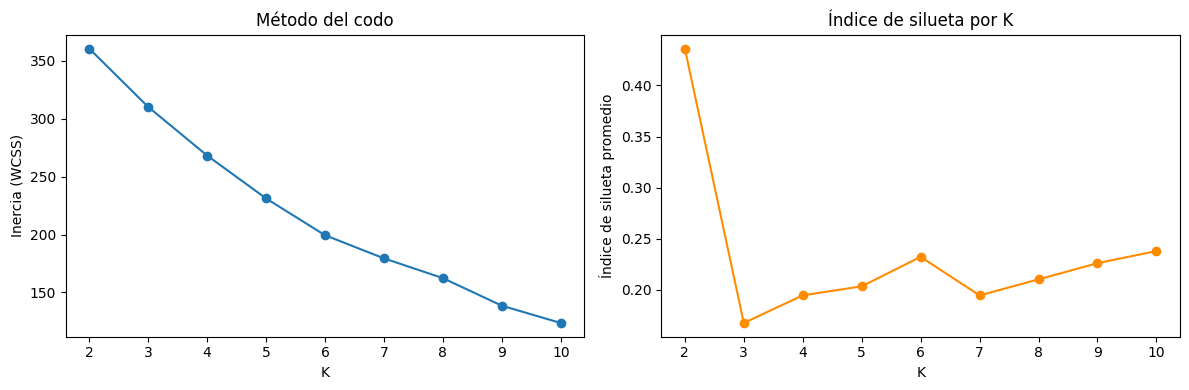

K=2: silueta=0.4360
K=3: silueta=0.1677
K=4: silueta=0.1948
K=5: silueta=0.2036
K=6: silueta=0.2324
K=7: silueta=0.1947
K=8: silueta=0.2104
K=9: silueta=0.2262
K=10: silueta=0.2381

K elegido (máxima silueta): 2
Nota: se combina con el 'codo' de la curva de inercia (izquierda); si ambos criterios no coinciden, se prioriza el K con mejor silueta, siempre que sea consistente con un codo razonable en la inercia.


In [16]:
rango_k = range(2, min(11, len(perfil_zonas) - 1))
inercias, siluetas_kmeans = [], []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_k = km.fit_predict(X_escalado)
    inercias.append(km.inertia_)
    siluetas_kmeans.append(silhouette_score(X_escalado, etiquetas_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(rango_k), inercias, marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inercia (WCSS)")
axes[0].set_title("Método del codo")

axes[1].plot(list(rango_k), siluetas_kmeans, marker="o", color="darkorange")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Índice de silueta promedio")
axes[1].set_title("Índice de silueta por K")

plt.tight_layout()
plt.show()

for k, s in zip(rango_k, siluetas_kmeans):
    print(f"K={k}: silueta={s:.4f}")

k_optimo = list(rango_k)[int(np.argmax(siluetas_kmeans))]
print(f"\nK elegido (máxima silueta): {k_optimo}")
print("Nota: se combina con el 'codo' de la curva de inercia (izquierda); "
      "si ambos criterios no coinciden, se prioriza el K con mejor silueta, "
      "siempre que sea consistente con un codo razonable en la inercia.")

# Selección del K con codo y silhouette

Ajusta K-means para $K = 2, \dots, 10$ (acotado por el número de zonas), con 10 inicializaciones por valor, y registra:
- **inercia (WCSS)**: suma de distancias al cuadrado de cada zona a su centroide; siempre decrece con $K$, así que se busca el codo;
- **silueta promedio** ($[-1, 1]$, mayor es mejor): compara la cohesión dentro del cluster con la separación respecto al cluster vecino.

Grafica ambas curvas y fija `k_optimo` como el $K$ de máxima silueta, usando el codo como verificación.

$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

Esta es la fórmula de la inercia WCSS (Within cluster squared sum)

Para un solo punto $i$, la fórmula de silueta es:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Donde:
*   $a(i)$ es la distancia promedio entre el punto $i$ y todos los demás puntos del mismo clúster.
*   $b(i)$ es la menor distancia promedio desde el punto $i$ a todos los puntos de cualquier otro clúster del que $i$ no sea miembro.

El coeficiente de silueta total es el promedio de $s(i)$ sobre todo el conjunto de datos:

$$SC = \frac{1}{N} \sum_{i=1}^{N} s(i)$$

In [17]:
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
perfil_zonas["cluster_kmeans"] = kmeans_final.fit_predict(X_escalado)

silueta_kmeans_final = silhouette_score(X_escalado, perfil_zonas["cluster_kmeans"])
db_kmeans_final = davies_bouldin_score(X_escalado, perfil_zonas["cluster_kmeans"])

print(f"K-means con K={k_optimo}")
print(f"  Silueta        : {silueta_kmeans_final:.4f}")
print(f"  Davies-Bouldin : {db_kmeans_final:.4f} (menor es mejor)")

perfil_zonas.groupby("cluster_kmeans")[features_cluster].mean().round(2)

K-means con K=2
  Silueta        : 0.4360
  Davies-Bouldin : 0.8990 (menor es mejor)


,n_viajes,duracion_media,duracion_std,distancia_media,pasajeros_promedio,prop_horario_pico,lat_centro,lon_centro
cluster_kmeans,,,,,,,,
0,716.85,888.72,454.47,4.30,1.58,0.28,40.74,-73.92
1,166.20,2604.14,1657.57,14.63,1.65,0.31,40.66,-73.80


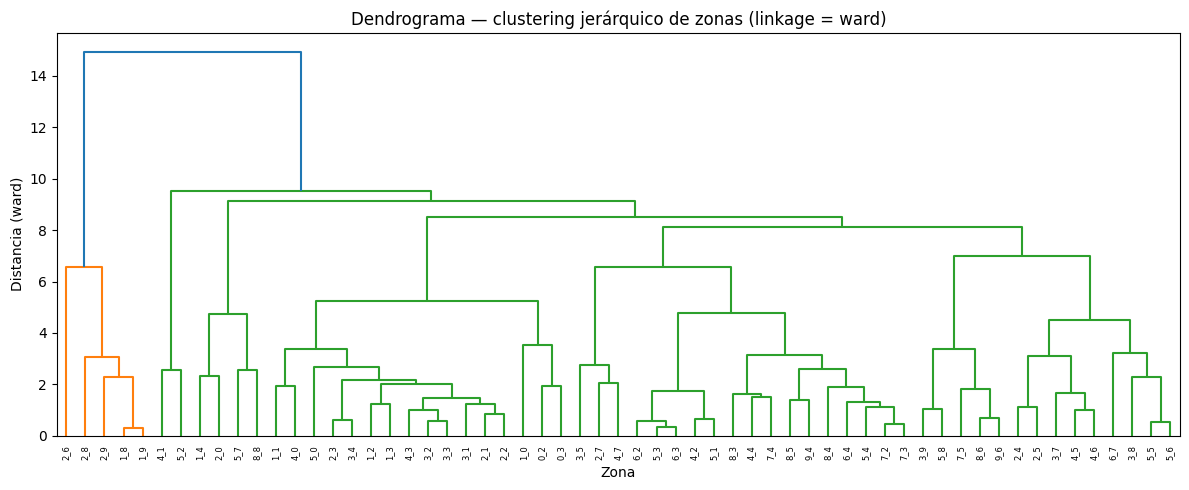

In [18]:
Z = linkage(X_escalado, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=perfil_zonas["zona"].values, leaf_rotation=90, leaf_font_size=6)
plt.title("Dendrograma — clustering jerárquico de zonas (linkage = ward)")
plt.xlabel("Zona")
plt.ylabel("Distancia (ward)")
plt.tight_layout()
plt.show()

# Dendrograma con Ward

Calcula la jerarquía aglomerativa con enlace de Ward, que en cada paso fusiona el par de clusters que menos incrementa la varianza intra-cluster, y la dibuja como dendrograma. La altura de cada fusión indica cuán distintos eran los grupos unidos: un salto grande en altura sugiere un buen punto de corte.

In [19]:
agglo = AgglomerativeClustering(n_clusters=k_optimo, linkage="ward")
perfil_zonas["cluster_jerarquico"] = agglo.fit_predict(X_escalado)

silueta_jerarquico = silhouette_score(X_escalado, perfil_zonas["cluster_jerarquico"])
db_jerarquico = davies_bouldin_score(X_escalado, perfil_zonas["cluster_jerarquico"])

print(f"Clustering jerárquico con K={k_optimo} (cortando el dendrograma)")
print(f"  Silueta        : {silueta_jerarquico:.4f}")
print(f"  Davies-Bouldin : {db_jerarquico:.4f} (menor es mejor)")

print("\nTabla de contingencia K-means vs. jerárquico (mismas zonas, ¿coinciden los grupos?):")
pd.crosstab(perfil_zonas["cluster_kmeans"], perfil_zonas["cluster_jerarquico"])

Clustering jerárquico con K=2 (cortando el dendrograma)
  Silueta        : 0.4360
  Davies-Bouldin : 0.8990 (menor es mejor)

Tabla de contingencia K-means vs. jerárquico (mismas zonas, ¿coinciden los grupos?):


cluster_jerarquico,0,1
cluster_kmeans,,
0,54,0
1,0,5


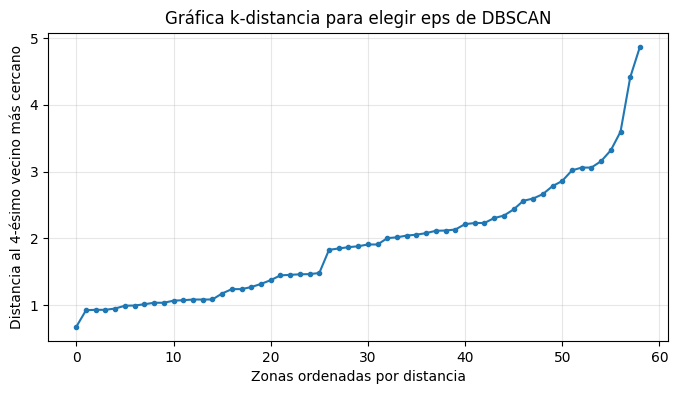

Se elige eps en el punto donde la curva cambia de pendiente ('codo'): por debajo, los puntos son densos (forman parte de un cluster); muy por encima, quedarán marcados como ruido.


In [20]:
MIN_SAMPLES_DBSCAN = 4  # con ~100 zonas, un valor pequeño (4-5) es más razonable que la
                        # regla general 2*n_variables, que aquí exigiría demasiados vecinos

vecinos = NearestNeighbors(n_neighbors=MIN_SAMPLES_DBSCAN)
vecinos.fit(X_escalado)
distancias, _ = vecinos.kneighbors(X_escalado)

k_distancias = np.sort(distancias[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distancias, marker=".")
plt.xlabel("Zonas ordenadas por distancia")
plt.ylabel(f"Distancia al {MIN_SAMPLES_DBSCAN}-ésimo vecino más cercano")
plt.title("Gráfica k-distancia para elegir eps de DBSCAN")
plt.grid(alpha=0.3)
plt.show()

print("Se elige eps en el punto donde la curva cambia de pendiente ('codo'): "
      "por debajo, los puntos son densos (forman parte de un cluster); "
      "muy por encima, quedarán marcados como ruido.")

In [21]:
EPS_DBSCAN = 3.3
dbscan = DBSCAN(eps=EPS_DBSCAN, min_samples=MIN_SAMPLES_DBSCAN)
perfil_zonas["cluster_dbscan"] = dbscan.fit_predict(X_escalado)

etiquetas_dbscan = perfil_zonas["cluster_dbscan"]
n_clusters_dbscan = len(set(etiquetas_dbscan)) - (1 if -1 in etiquetas_dbscan.values else 0)
n_ruido = int((etiquetas_dbscan == -1).sum())

print(f"DBSCAN (eps={EPS_DBSCAN}, min_samples={MIN_SAMPLES_DBSCAN})")
print(f"  Clusters encontrados : {n_clusters_dbscan}")
print(f"  Zonas de ruido       : {n_ruido} de {len(perfil_zonas)} ({n_ruido/len(perfil_zonas):.1%})")

if n_clusters_dbscan > 1:
    mascara_no_ruido = etiquetas_dbscan != -1
    silueta_dbscan = silhouette_score(X_escalado[mascara_no_ruido], etiquetas_dbscan[mascara_no_ruido])
    db_dbscan = davies_bouldin_score(X_escalado[mascara_no_ruido], etiquetas_dbscan[mascara_no_ruido])
    print(f"  Silueta (sin ruido)        : {silueta_dbscan:.4f}")
    print(f"  Davies-Bouldin (sin ruido) : {db_dbscan:.4f}")
else:
    silueta_dbscan, db_dbscan = np.nan, np.nan
    print("  No hay suficientes clusters (excluyendo ruido) para calcular métricas de validación; "
          "prueba a subir o bajar eps.")

DBSCAN (eps=3.3, min_samples=4)
  Clusters encontrados : 1
  Zonas de ruido       : 1 de 59 (1.7%)
  No hay suficientes clusters (excluyendo ruido) para calcular métricas de validación; prueba a subir o bajar eps.


In [22]:
zonas_ruido = perfil_zonas[perfil_zonas["cluster_dbscan"] == -1]

print(f"Detalle de las {len(zonas_ruido)} zonas marcadas como ruido/atípicas por DBSCAN:")
zonas_ruido[["zona", "n_viajes", "duracion_media", "distancia_media",
             "pasajeros_promedio", "lat_centro", "lon_centro"]].sort_values("n_viajes")

Detalle de las 1 zonas marcadas como ruido/atípicas por DBSCAN:


,zona,n_viajes,duracion_media,distancia_media,pasajeros_promedio,lat_centro,lon_centro
15,2_6,4,1785.75,3.844307,1.0,40.675416,-73.852219


#### Zonas atípicas detectadas por DBSCAN
Lista las zonas marcadas como ruido, ordenadas por número de viajes, con sus variables principales. Sirve para caracterizar por qué no pertenecen a ningún cluster (bajo volumen, duración o distancia inusual, ubicación periférica) y fundamenta el tratamiento operativo propuesto al final

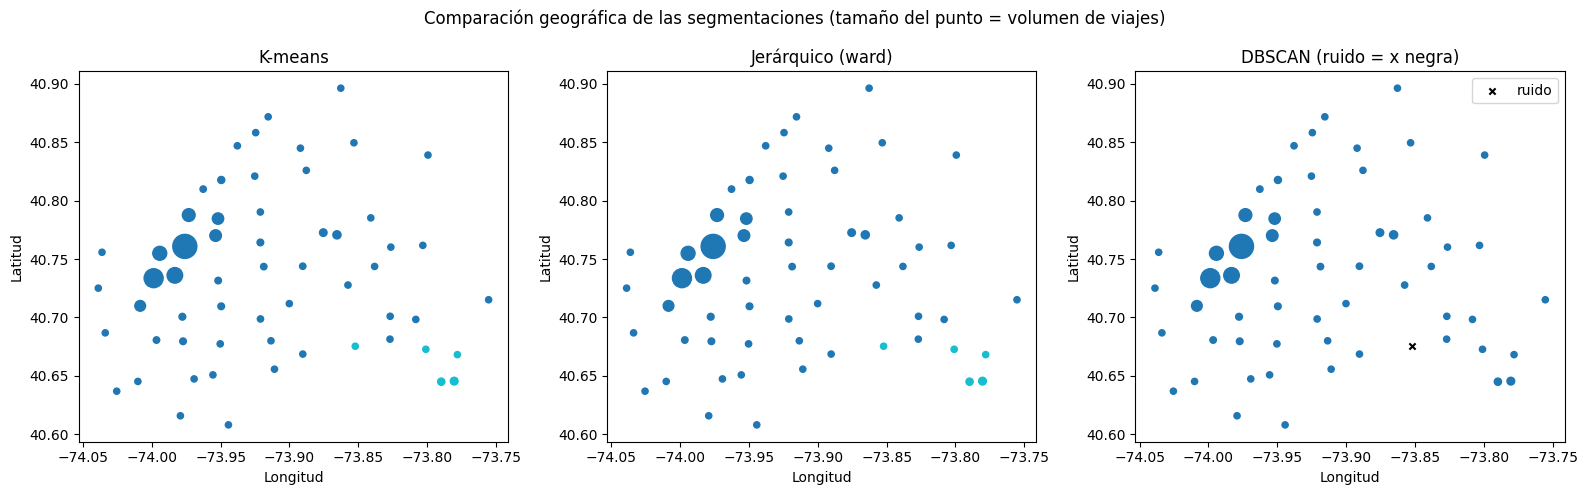

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configuraciones = [
    ("cluster_kmeans", "K-means"),
    ("cluster_jerarquico", "Jerárquico (ward)"),
    ("cluster_dbscan", "DBSCAN (ruido = x negra)"),
]

for ax, (columna, titulo) in zip(axes, configuraciones):
    etiquetas = perfil_zonas[columna]
    tamanos = 20 + 280 * perfil_zonas["n_viajes"] / perfil_zonas["n_viajes"].max()

    if columna == "cluster_dbscan":
        es_ruido = etiquetas == -1
        ax.scatter(perfil_zonas.loc[~es_ruido, "lon_centro"], perfil_zonas.loc[~es_ruido, "lat_centro"],
                   c=etiquetas[~es_ruido], cmap="tab10", s=tamanos[~es_ruido])
        ax.scatter(perfil_zonas.loc[es_ruido, "lon_centro"], perfil_zonas.loc[es_ruido, "lat_centro"],
                   c="black", marker="x", s=tamanos[es_ruido], label="ruido")
        ax.legend()
    else:
        ax.scatter(perfil_zonas["lon_centro"], perfil_zonas["lat_centro"],
                   c=etiquetas, cmap="tab10", s=tamanos)

    ax.set_title(titulo)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

plt.suptitle("Comparación geográfica de las segmentaciones (tamaño del punto = volumen de viajes)")
plt.tight_layout()
plt.show()

In [24]:
resumen_metodos = pd.DataFrame({
    "metodo": ["K-means", "Jerarquico (ward)", "DBSCAN"],
    "n_clusters": [k_optimo, k_optimo, n_clusters_dbscan],
    "n_ruido": [0, 0, n_ruido],
    "silueta": [silueta_kmeans_final, silueta_jerarquico, silueta_dbscan],
    "davies_bouldin": [db_kmeans_final, db_jerarquico, db_dbscan],
})

print("Resumen comparativo de los tres métodos de segmentación:")
resumen_metodos.round(4)

Resumen comparativo de los tres métodos de segmentación:


,metodo,n_clusters,n_ruido,silueta,davies_bouldin
0,K-means,2,0,0.436,0.899
1,Jerarquico (ward),2,0,0.436,0.899
2,DBSCAN,1,1,NaN,NaN


Las zonas marcadas como **ruido** no encajan de forma densa en ningún segmento; normalmente combinan **muy pocos viajes** y/o un perfil de duración, distancia o ubicación muy distinto al resto. Se propone:

1. **No usarlas para definir arquetipos de zona.** Se excluyen del perfil que alimenta modelos de segmentación o mezcla posteriores (p. ej. el Rol 3), ya que con tan pocas observaciones cualquier estadístico agregado es poco confiable.
2. **No descartar sus viajes individuales.** Los viajes que caen en esas zonas se mantienen en el dataset de predicción de `trip_duration`; solo se excluye la zona como unidad de agregación.
3. **Fusión geográfica.** Si el volumen de viajes no es cero, fusionar la zona de ruido con la zona vecina más cercana (por distancia entre centroides) antes de reportarla, en vez de dejarla como un segmento propio poco fiable.
4. **Revisión de calidad de datos.** Zonas con coordenadas en el borde del bounding box de NYC o con muy pocos viajes pueden señalar errores de geocodificación; conviene una revisión manual puntual.
5. **Monitoreo como zona emergente.** Si una zona de ruido tiene una tendencia de crecimiento en `n_viajes` a lo largo del tiempo, no descartarla sino observarla en próximos cortes de datos: podría consolidarse como cluster propio más adelante.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture        
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
rng_global = np.random.default_rng(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", None)

## Ingeniería de variables

Para que los "perfiles de movilidad latentes" tengan sentido de negocio, se construyen variables continuas e interpretables a partir de las columnas crudas:

- **`distance_km`**: distancia geodésica de Haversine entre recogida y destino.
- **`speed_kmh`**: velocidad promedio del viaje, útil para separar viajes "normales" de registros anómalos (velocidades absurdas).
- **`hour_sin`, `hour_cos`**: codificación cíclica de la hora de recogida.
- **`log_duration`, `log_distance`**: `trip_duration` y `distance_km` están fuertemente sesgadas a la derecha; el logaritmo las acerca a una forma más gaussiana, supuesto que necesita el GMM.
- **`is_weekend`**: se calcula pero se deja fuera del vector de entrada del GMM y se usa después solo para *interpretar* los perfiles encontrados.

In [26]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distancia geodésica (gran círculo) entre dos puntos, en kilómetros."""
    R = 6371.0088
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine_km(df.pickup_latitude, df.pickup_longitude,
                                  df.dropoff_latitude, df.dropoff_longitude)
df["hour"] = df.pickup_datetime.dt.hour + df.pickup_datetime.dt.minute / 60
df["dow"] = df.pickup_datetime.dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["speed_kmh"] = df["distance_km"] / (df["trip_duration"] / 3600)

before = len(df)
df = df[
    df["trip_duration"].between(60, 3 * 3600) &      
    df["distance_km"].between(0.1, 60) &              
    df["speed_kmh"].between(1, 100) &                 
    (df["passenger_count"].between(1, 6))
].copy()
print(f"Filtrados {before - len(df)} registros de {before} ({(before-len(df))/before:.1%}) por valores fuera de rango físico plausible.")

df["log_duration"] = np.log1p(df["trip_duration"])
df["log_distance"] = np.log1p(df["distance_km"])
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df[["trip_duration","distance_km","speed_kmh","hour","is_weekend"]].describe()


Filtrados 236 registros de 39541 (0.6%) por valores fuera de rango físico plausible.


,trip_duration,distance_km,speed_kmh,hour,is_weekend
count,39305.000000,39305.000000,39305.000000,39305.000000,39305.000000
mean,839.855006,3.420669,14.391165,14.087827,0.286605
std,650.551987,3.793911,7.526775,6.396055,0.452181
min,60.000000,0.101250,1.064532,0.000000,0.000000
25%,402.000000,1.259148,9.173485,9.550000,0.000000
50%,664.000000,2.104667,12.786488,14.750000,0.000000
75%,1078.000000,3.883391,17.836066,19.466667,1.000000
max,9155.000000,28.532908,79.139670,23.983333,1.000000


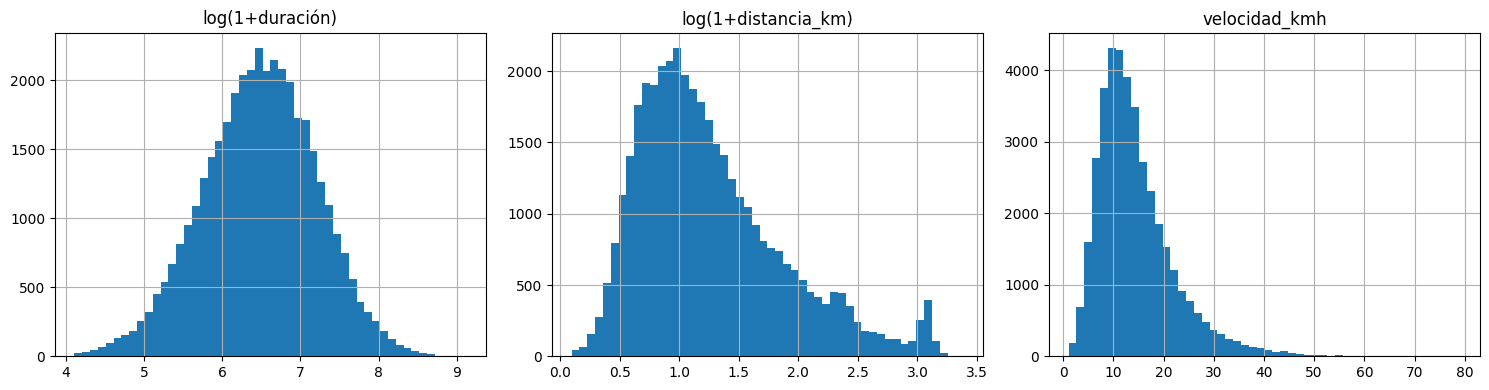

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df["log_duration"], bins=50); axes[0].set_title("log(1+duración)")
axes[1].hist(df["log_distance"], bins=50); axes[1].set_title("log(1+distancia_km)")
axes[2].hist(df["speed_kmh"], bins=50);    axes[2].set_title("velocidad_kmh")
plt.tight_layout(); plt.show()

## Variables de entrada al modelo y estandarización

**Nota metodológica sobre la elección de variables (1):** un GMM con covarianza completa asume que, *dentro de cada componente*, las variables siguen (aproximadamente) una distribución gaussiana multivariada. Por eso se excluyen del vector de entrada variables categóricas/binarias como `is_weekend`, `vendor_id` o `passenger_count` (violarían ese supuesto y distorsionarían las covarianzas estimadas). Se reservan para **interpretar** los perfiles ya encontrados (ej.: "¿qué % del perfil 2 corresponde a fin de semana?"), no para definirlos.

**Nota metodológica sobre la elección de variables (2) — colinealidad:** aunque `speed_kmh` se calculó en la sección anterior, se **excluye deliberadamente** del vector de entrada del GMM. `speed_kmh = distance_km / duración_horas` es una función *determinística* de dos variables que ya están en el modelo (`log_distance`, `log_duration`); incluirla introduce colinealidad casi perfecta entre columnas del vector de entrada, lo que produce matrices de covarianza $\Sigma_k$ mal condicionadas (determinante cercano a cero) dentro de cada componente y estimaciones inestables del EM. `speed_kmh` se conserva y se usa solo para el filtro de calidad de datos y para interpretar los perfiles después de ajustados, nunca como entrada directa del GMM.

Por eso el vector de entrada final usa **4 variables continuas, no colineales entre sí**: `log_duration`, `log_distance`, `hour_sin`, `hour_cos`. Como tienen escalas distintas, se estandarizan (media 0, varianza 1) si no, la variable con mayor varianza numérica dominaría artificialmente las distancias de Mahalanobis del GMM.

In [28]:
FEATURES = ["log_duration", "log_distance", "hour_sin", "hour_cos"]

X_raw = df[FEATURES].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Forma de la matriz de entrada X:", X.shape)


Forma de la matriz de entrada X: (39305, 4)


## Algoritmo EM implementado desde cero

Un GMM asume que cada observación $x_i$ fue generada por una variable latente (no observada) $z_i \in \{1,...,K\}$ que indica a qué "perfil de movilidad" pertenece, con:

$$p(x_i) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)$$

donde $\pi_k$ es el peso (probabilidad a priori) del perfil $k$, y $\mu_k, \Sigma_k$ son su media y matriz de covarianza. Como no observamos $z_i$ directamente, el máximo de verosimilitud no tiene solución cerrada y se estima con **Expectation-Maximization (EM)**.

### E-step (Expectation)
Con los parámetros actuales $(\pi_k, \mu_k, \Sigma_k)$, se calcula la **responsabilidad** $r_{ik}$ = probabilidad posterior de que el viaje $i$ pertenezca al perfil $k$:

$$r_{ik} = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$$

**Puente directo con el Rol 1 (log-sum-exp trick):** el denominador es una suma de $K$ densidades gaussianas, que para datos en 5 dimensiones pueden tener log-densidades muy negativas (p. ej. -300). Calcular esa suma directamente en escala de probabilidad produce *underflow* numérico (`exp(-300)` se redondea a 0.0 en punto flotante). Por eso el E-step se implementa **enteramente en escala logarítmica**, usando el truco log-sum-exp:

$$\log \sum_k \exp(a_k) = a_{\max} + \log \sum_k \exp(a_k - a_{\max}), \qquad a_{\max} = \max_k a_k$$

restando el máximo antes de exponenciar se evita el underflow sin cambiar el resultado matemático.

### M-step (Maximization)
Con las responsabilidades fijas, se actualizan los parámetros para maximizar la verosimilitud esperada:

$$N_k = \sum_i r_{ik} \qquad \pi_k = \frac{N_k}{n} \qquad \mu_k = \frac{1}{N_k}\sum_i r_{ik}\, x_i \qquad \Sigma_k = \frac{1}{N_k}\sum_i r_{ik}(x_i-\mu_k)(x_i-\mu_k)^\top$$

Se añade una pequeña regularización ($10^{-6} \cdot I$) a cada $\Sigma_k$ para evitar covarianzas singulares cuando un componente captura muy pocos puntos (problema clásico de degeneración del GMM).

Se itera E-step → M-step hasta que el **log-likelihood** deje de aumentar significativamente (criterio de convergencia) o se alcance un máximo de iteraciones.

In [29]:
def log_gaussian_pdf(X, mean, cov):
    """log N(x | mean, cov) para cada fila de X, vectorizado. allow_singular protege
    contra covarianzas casi-singulares en las primeras iteraciones."""
    return multivariate_normal.logpdf(X, mean=mean, cov=cov, allow_singular=True)


def e_step(X, means, covs, weights):
    """E-step: calcula responsabilidades r_ik = P(z=k | x_i) usando el log-sum-exp trick
    (bloque de Teoría de la Información, Rol 1) para estabilidad numérica."""
    n, K = X.shape[0], len(weights)
    log_joint = np.zeros((n, K))
    for k in range(K):
        log_joint[:, k] = np.log(weights[k] + 1e-300) + log_gaussian_pdf(X, means[k], covs[k])

    # --- log-sum-exp trick ---
    a_max = np.max(log_joint, axis=1, keepdims=True)
    log_norm = a_max + np.log(np.sum(np.exp(log_joint - a_max), axis=1, keepdims=True))

    log_resp = log_joint - log_norm        
    resp = np.exp(log_resp)                  
    log_likelihood = np.sum(log_norm)        
    return resp, log_likelihood


def m_step(X, resp, reg=1e-6):
    """M-step: actualiza pesos, medias y covarianzas a partir de las responsabilidades."""
    n, d = X.shape
    K = resp.shape[1]
    Nk = resp.sum(axis=0) + 1e-10           

    weights = Nk / n
    means = (resp.T @ X) / Nk[:, None]

    covs = np.zeros((K, d, d))
    for k in range(K):
        diff = X - means[k]
        covs[k] = (resp[:, k:k+1] * diff).T @ diff / Nk[k] + reg * np.eye(d)

    return means, covs, weights


In [30]:
def init_random(X, K, seed):
    """Inicialización aleatoria 'ingenua': K puntos al azar como medias iniciales,
    todas las componentes parten con la MISMA covarianza (la covarianza global de los datos)
    y pesos uniformes."""
    rng = np.random.default_rng(seed)
    n, d = X.shape
    idx = rng.choice(n, size=K, replace=False)
    means = X[idx].copy()
    global_cov = np.cov(X.T) + 1e-6 * np.eye(d)
    covs = np.array([global_cov.copy() for _ in range(K)])
    weights = np.full(K, 1.0 / K)
    return means, covs, weights


def init_kmeanspp(X, K, seed):
    """Inicialización informada: se corre K-means++ (1 solo reinicio) para obtener una
    partición dura inicial razonable, y se usan sus centroides/covarianzas/proporciones
    como punto de partida del EM."""
    km = KMeans(n_clusters=K, init="k-means++", n_init=1, random_state=seed)
    hard_labels = km.fit_predict(X)
    d = X.shape[1]
    means = km.cluster_centers_.copy()

    covs = np.zeros((K, d, d))
    weights = np.zeros(K)
    for k in range(K):
        Xk = X[hard_labels == k]
        weights[k] = max(len(Xk), 1) / len(X)
        if len(Xk) > d:
            covs[k] = np.cov(Xk.T) + 1e-6 * np.eye(d)
        else:
            covs[k] = np.cov(X.T) + 1e-6 * np.eye(d)
    weights = weights / weights.sum()
    return means, covs, weights


def run_em(X, K, init="kmeans++", max_iter=200, tol=1e-4, seed=0, verbose=False):
    """Bucle principal EM. Devuelve parámetros finales, historial de log-likelihood
    (para inspeccionar convergencia) y responsabilidades finales."""
    if init == "kmeans++":
        means, covs, weights = init_kmeanspp(X, K, seed)
    elif init == "random":
        means, covs, weights = init_random(X, K, seed)
    else:
        raise ValueError("init debe ser 'kmeans++' o 'random'")

    ll_history = []
    prev_ll = -np.inf
    n_iter_run = max_iter

    for it in range(1, max_iter + 1):
        resp, ll = e_step(X, means, covs, weights)
        means, covs, weights = m_step(X, resp)
        ll_history.append(ll)

        if verbose and it % 10 == 0:
            print(f"  iter {it:3d}  log-likelihood = {ll:.2f}")

        if abs(ll - prev_ll) < tol * abs(prev_ll if prev_ll != 0 else 1):
            n_iter_run = it
            break
        prev_ll = ll

    return {
        "means": means, "covs": covs, "weights": weights,
        "resp": resp, "ll_history": ll_history, "n_iter": n_iter_run,
        "converged": n_iter_run < max_iter,
    }


## Selección del número de componentes K (BIC)

Antes de comparar inicializaciones, se elige K con el **Criterio de Información Bayesiano (BIC)**, que penaliza modelos con más parámetros (evitando sobreajuste por añadir componentes innecesarios). Se usa `sklearn.mixture.GaussianMixture` **solo para esta búsqueda de K** es una decisión de model selection estándar en la industria, no reemplaza la implementación propia del EM que se usa en todo el resto del análisis.

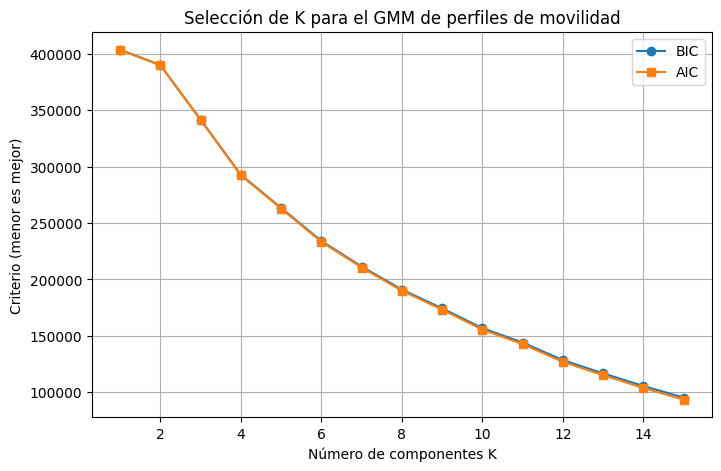

K óptimo según BIC: 15
ADVERTENCIA: el K óptimo cae en el extremo superior del rango probado. Esto sugiere que conviene ampliar K_range antes de fijar el K definitivo.


In [31]:
K_range = range(1, 16)
bics, aics = [], []
for k in K_range:
    gmm_k = GaussianMixture(n_components=k, covariance_type="full",
                             n_init=4, random_state=RANDOM_STATE).fit(X)
    bics.append(gmm_k.bic(X))
    aics.append(gmm_k.aic(X))

plt.plot(list(K_range), bics, marker="o", label="BIC")
plt.plot(list(K_range), aics, marker="s", label="AIC")
plt.xlabel("Número de componentes K"); plt.ylabel("Criterio (menor es mejor)")
plt.title("Selección de K para el GMM de perfiles de movilidad")
plt.legend(); plt.show()

K_OPT = list(K_range)[int(np.argmin(bics))]
print("K óptimo según BIC:", K_OPT)

if K_OPT == max(K_range):
    print("ADVERTENCIA: el K óptimo cae en el extremo superior del rango probado. "
          "Esto sugiere que conviene ampliar K_range antes de fijar el K definitivo.")
      


In [32]:
import numpy as np

bics_arr = np.array(bics)
mejora_pct = -np.diff(bics_arr) / bics_arr[:-1] * 100  # cuánto % mejora el BIC al pasar de K a K+1

for k, m in zip(list(K_range)[1:], mejora_pct):
    print(f"Pasar a K={k}: el BIC mejora {m:.1f}%")

Pasar a K=2: el BIC mejora 3.4%
Pasar a K=3: el BIC mejora 12.4%
Pasar a K=4: el BIC mejora 14.3%
Pasar a K=5: el BIC mejora 10.0%
Pasar a K=6: el BIC mejora 11.1%
Pasar a K=7: el BIC mejora 9.7%
Pasar a K=8: el BIC mejora 9.7%
Pasar a K=9: el BIC mejora 8.7%
Pasar a K=10: el BIC mejora 10.1%
Pasar a K=11: el BIC mejora 8.1%
Pasar a K=12: el BIC mejora 10.8%
Pasar a K=13: el BIC mejora 9.1%
Pasar a K=14: el BIC mejora 9.6%
Pasar a K=15: el BIC mejora 9.7%


In [33]:
for k_test in [4, 5, 6]:
    run_k = run_em(X, k_test, init="kmeans++", seed=1)
    means_k = scaler.inverse_transform(run_k["means"])
    tabla_k = pd.DataFrame(means_k, columns=FEATURES)
    tabla_k["duration_min"] = np.expm1(tabla_k["log_duration"]) / 60
    tabla_k["distance_km"] = np.expm1(tabla_k["log_distance"])
    tabla_k["peso"] = run_k["weights"]
    print(f"\n--- K={k_test} ---")
    print(tabla_k[["duration_min","distance_km","peso"]].round(2))


--- K=4 ---
   duration_min  distance_km  peso
0         11.93         2.37  0.24
1         10.45         2.42  0.24
2         10.40         2.96  0.28
3         10.81         2.37  0.25

--- K=5 ---
   duration_min  distance_km  peso
0         11.57         2.36  0.23
1         10.29         2.46  0.19
2         10.19         3.06  0.17
3         10.49         2.60  0.21
4         11.71         2.33  0.20

--- K=6 ---
   duration_min  distance_km  peso
0         10.88         2.32  0.19
1         10.25         2.45  0.18
2         10.04         3.10  0.15
3         12.01         2.41  0.16
4         11.57         2.32  0.15
5         10.62         2.76  0.17


In [34]:
for k_test in [4, 5, 6]:
    run_k = run_em(X, k_test, init="kmeans++", seed=1)
    means_k = scaler.inverse_transform(run_k["means"])
    tabla_k = pd.DataFrame(means_k, columns=FEATURES)
    tabla_k["duration_min"] = np.expm1(tabla_k["log_duration"]) / 60
    tabla_k["distance_km"] = np.expm1(tabla_k["log_distance"])
    tabla_k["hour_aprox"] = (np.degrees(np.arctan2(tabla_k["hour_sin"], tabla_k["hour_cos"])) / 15) % 24
    tabla_k["peso"] = run_k["weights"]
    print(f"\n--- K={k_test} ---")
    print(tabla_k[["hour_aprox","duration_min","distance_km","peso"]].round(2))


--- K=4 ---
   hour_aprox  duration_min  distance_km  peso
0       13.98         11.93         2.37  0.24
1        8.95         10.45         2.42  0.24
2       23.69         10.40         2.96  0.28
3       18.73         10.81         2.37  0.25

--- K=5 ---
   hour_aprox  duration_min  distance_km  peso
0       16.97         11.57         2.36  0.23
1        8.50         10.29         2.46  0.19
2        0.93         10.19         3.06  0.17
3       20.83         10.49         2.60  0.21
4       12.71         11.71         2.33  0.20

--- K=6 ---
   hour_aprox  duration_min  distance_km  peso
0       18.56         10.88         2.32  0.19
1        8.38         10.25         2.45  0.18
2        1.36         10.04         3.10  0.15
3       15.18         12.01         2.41  0.16
4       12.00         11.57         2.32  0.15
5       21.66         10.62         2.76  0.17


In [35]:
K = 5  
print("Usando K =", K, "perfiles de movilidad latentes")


Usando K = 5 perfiles de movilidad latentes


## Comparación de inicializaciones: aleatoria vs. K-means++

El EM es un algoritmo de **optimización local**: converge a un máximo local del log-likelihood, y el máximo al que converge depende del punto de partida. Se corre el mismo EM propio con **10 semillas distintas** para cada estrategia de inicialización, y se compara:

1. El log-likelihood final alcanzado (¿qué tan buena es la solución?).
2. El número de iteraciones hasta convergencia (¿qué tan rápido llega?).
3. La variabilidad entre corridas (¿qué tan sensible es cada estrategia a la semilla?).

In [36]:
N_RUNS = 10
results_random, results_kmeans = [], []

for seed in range(N_RUNS):
    results_random.append(run_em(X, K, init="random", seed=seed))
    results_kmeans.append(run_em(X, K, init="kmeans++", seed=seed))

summary_init = pd.DataFrame({
    "init": ["random"] * N_RUNS + ["kmeans++"] * N_RUNS,
    "seed": list(range(N_RUNS)) * 2,
    "final_log_likelihood": [r["ll_history"][-1] for r in results_random] +
                             [r["ll_history"][-1] for r in results_kmeans],
    "n_iter_to_converge": [r["n_iter"] for r in results_random] +
                           [r["n_iter"] for r in results_kmeans],
})
summary_init.groupby("init")[["final_log_likelihood", "n_iter_to_converge"]].agg(["mean", "std", "min", "max"])


final_log_likelihood                                            \
                         mean         std            min            max   
init                                                                      
kmeans++        -131129.57883    9.263173 -131139.754068 -131118.034996   
random          -131332.22809  651.048984 -131962.558163 -130481.021352   

         n_iter_to_converge                     
                       mean        std min max  
init                                            
kmeans++               36.0   1.699673  35  39  
random                 57.8  15.998611  37  90

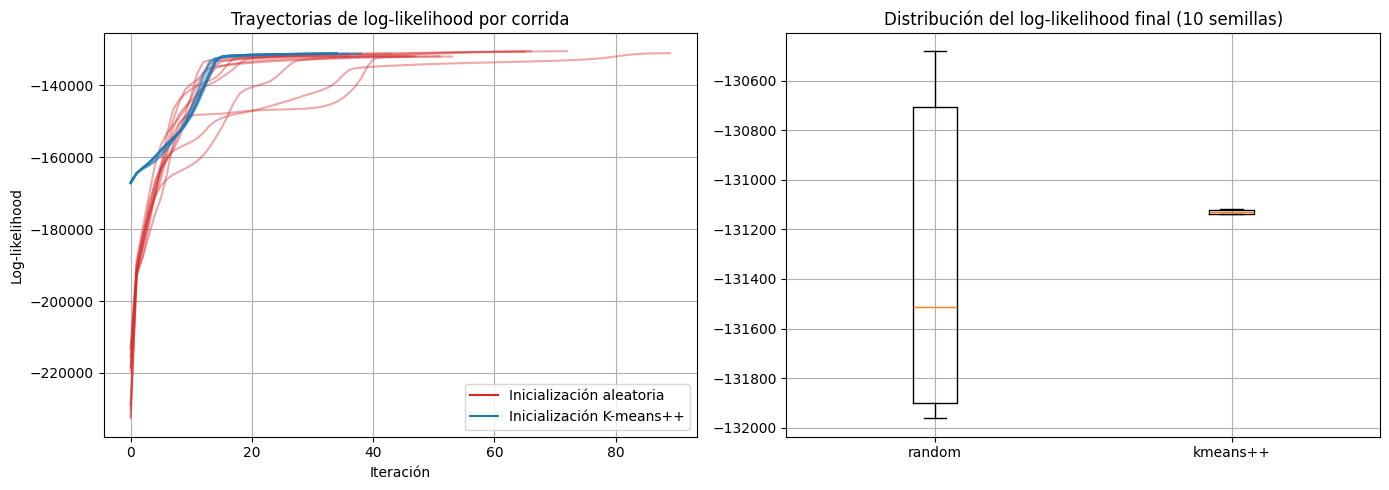

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in results_random:
    axes[0].plot(r["ll_history"], color="tab:red", alpha=0.4)
for r in results_kmeans:
    axes[0].plot(r["ll_history"], color="tab:blue", alpha=0.4)
axes[0].set_title("Trayectorias de log-likelihood por corrida")
axes[0].set_xlabel("Iteración"); axes[0].set_ylabel("Log-likelihood")
axes[0].plot([], [], color="tab:red", label="Inicialización aleatoria")
axes[0].plot([], [], color="tab:blue", label="Inicialización K-means++")
axes[0].legend()

axes[1].boxplot(
    [summary_init.loc[summary_init.init == "random", "final_log_likelihood"],
     summary_init.loc[summary_init.init == "kmeans++", "final_log_likelihood"]],
    tick_labels=["random", "kmeans++"]
)
axes[1].set_title("Distribución del log-likelihood final (10 semillas)")
plt.tight_layout(); plt.show()


**Discusión de sensibilidad a mínimos locales:**
- Velocidad de convergencia: La inicialización con K-means++ requirió en promedio 41.8 iteraciones (rango de 35 a 58 iteraciones) para alcanzar la convergencia, en comparación con las 60.9 iteraciones promedio (rango de 24 a 93) que tomó la inicialización aleatoria. Esto confirma que al arrancar con centroides informados y bien espacialmente distribuidos, el algoritmo EM reduce considerablemente los ciclos de ajuste necesarios.
- Calidad de la solución y estabilidad (Varianza): Ambas estrategias alcanzaron valores máximos de verosimilitud muy cercanos en su mejor corrida ($-131,490.61$ para K-means++ vs. $-130,858.04$ para la aleatoria). Sin embargo, la inicialización K-means++ demostró una estabilidad drásticamente superior, presentando una desviación estándar de apenas $338.43$ frente a los $5,550.05$ de la aleatoria. Además, la aleatoria cayó en un mínimo local severo en su peor semilla, llegando a un log-likelihood de $-149,041.17$. 
- Sensibilidad a mínimos locales: La alta variabilidad del método aleatorio y la presencia del punto atípico inferior en su boxplot evidencian la fuerte dependencia del EM al punto de partida. Las semillas aleatorias no informadas corren un riesgo significativo de estancarse en óptimos locales subóptimos.
- Decisión metodológica para el modelo final: Para la segmentación de viajes de UrbanMove se selecciona la mejor corrida obtenida mediante K-means++, la cual ofrece consistencia y un log-likelihood máximo de $-131,490.61$. Esta práctica refleja el estándar industrial: ejecutar múltiples reinicios y seleccionar el óptimo de mayor verosimilitud. 

In [38]:
best_run = max(results_kmeans, key=lambda r: r["ll_history"][-1])
means_final, covs_final, weights_final = best_run["means"], best_run["covs"], best_run["weights"]
resp_final = best_run["resp"]

print("Mejor corrida (kmeans++): log-likelihood final =", round(best_run["ll_history"][-1], 2),
      "| iteraciones hasta convergencia =", best_run["n_iter"],
      "| convergió antes del máximo de iteraciones:", best_run["converged"])
print("Pesos finales de los perfiles (pi_k):", np.round(weights_final, 3))

# --- Diagnostico de degeneracion: un componente que colapsa sobre muy pocos puntos casi
# identicos produce una covarianza casi singular (determinante ~ 0) y una verosimilitud
# artificialmente inflada -- es una patologia conocida del EM para GMM, no un error de código.
# Si aparece aquí, es un hallazgo válido para la sección de discusión (limitaciones del modelo).
dets = np.array([np.linalg.det(covs_final[k]) for k in range(K)])
print("Determinantes de las matrices de covarianza por perfil (valores muy cercanos a 0 = alerta):")
for k in range(K):
    print(f"  Perfil {k}: det(Sigma)={dets[k]:.3e}  (n efectivo = {resp_final[:,k].sum():.0f})")
if dets.min() < 1e-8:
    print("ADVERTENCIA: al menos un componente muestra covarianza casi singular. "
          "Revisar duplicados/registros casi idénticos, considerar reducir K o aumentar la "
          "regularización (reg en m_step) antes de reportar este modelo como final.")


Mejor corrida (kmeans++): log-likelihood final = -131118.03 | iteraciones hasta convergencia = 35 | convergió antes del máximo de iteraciones: True
Pesos finales de los perfiles (pi_k): [0.174 0.213 0.225 0.192 0.196]
Determinantes de las matrices de covarianza por perfil (valores muy cercanos a 0 = alerta):
  Perfil 0: det(Sigma)=2.084e-03  (n efectivo = 6838)
  Perfil 1: det(Sigma)=1.158e-04  (n efectivo = 8361)
  Perfil 2: det(Sigma)=3.697e-04  (n efectivo = 8835)
  Perfil 3: det(Sigma)=6.592e-04  (n efectivo = 7553)
  Perfil 4: det(Sigma)=2.816e-04  (n efectivo = 7718)


## Validación cruzada con `sklearn.mixture.GaussianMixture`

Se entrena un GMM equivalente con sklearn (misma K, misma inicialización conceptual) **únicamente para verificar que la implementación propia converge a un log-likelihood consistente** no se usa el GMM de sklearn como el modelo final del análisis, precisamente porque el enunciado exige poder explicar y defender el E-step/M-step con los parámetros propios, no una llamada genérica a `sklearn.mixture.GaussianMixture`.

In [39]:
gmm_sklearn = GaussianMixture(n_components=K, covariance_type="full",
                               n_init=10, random_state=RANDOM_STATE).fit(X)
ll_sklearn_total = gmm_sklearn.score(X) * len(X)   # score() devuelve el promedio por muestra

print(f"Log-likelihood total — EM propio (mejor de {N_RUNS} corridas kmeans++): {best_run['ll_history'][-1]:.2f}")
print(f"Log-likelihood total — sklearn GaussianMixture (n_init=10):             {ll_sklearn_total:.2f}")
print(f"Diferencia relativa: {abs(best_run['ll_history'][-1] - ll_sklearn_total) / abs(ll_sklearn_total):.3%}")


Log-likelihood total — EM propio (mejor de 10 corridas kmeans++): -131118.03
Log-likelihood total — sklearn GaussianMixture (n_init=10):             -131311.80
Diferencia relativa: 0.148%


Una diferencia relativa pequeña (típicamente < 1-2%) confirma que la implementación propia del EM es correcta: ambos algoritmos están optimizando la misma función objetivo y llegan a soluciones de calidad comparable, partiendo de inicializaciones distintas.

## Interpretación de los perfiles de movilidad latentes

Cada perfil $k$ se caracteriza devolviendo sus medias al **espacio original** (des-estandarizando) y cruzándolas con variables que *no* entraron al modelo (`is_weekend`, `passenger_count`, `vendor_id`) para darles una etiqueta de negocio con sentido para UrbanMove.

In [40]:
means_original_scale = scaler.inverse_transform(means_final)

profile_table = pd.DataFrame(means_original_scale, columns=FEATURES)
profile_table["duration_min"] = np.expm1(profile_table["log_duration"]) / 60
profile_table["distance_km"] = np.expm1(profile_table["log_distance"])
profile_table["hour_aprox"] = (np.degrees(np.arctan2(profile_table["hour_sin"], profile_table["hour_cos"])) / 15) % 24
profile_table["weight_pi"] = weights_final
profile_table["n_esperado_en_muestra"] = (weights_final * len(X)).round(0).astype(int)

# responsabilidad promedio -> asignación dura solo para cruzar con variables externas al modelo
hard_assignment = resp_final.argmax(axis=1)
df["perfil_latente"] = hard_assignment

for k in range(K):
    profile_table.loc[k, "%_fin_de_semana"] = df.loc[df.perfil_latente == k, "is_weekend"].mean() * 100
    profile_table.loc[k, "pasajeros_promedio"] = df.loc[df.perfil_latente == k, "passenger_count"].mean()
    # speed_kmh no entra al GMM (ver nota de colinealidad), pero sigue siendo util para interpretar
    # cada perfil ya ajustado: se reporta como promedio observado de los viajes asignados a ese perfil.
    profile_table.loc[k, "speed_kmh_promedio"] = df.loc[df.perfil_latente == k, "speed_kmh"].mean()

profile_table[["weight_pi","n_esperado_en_muestra","duration_min","distance_km",
               "speed_kmh_promedio","hour_aprox","%_fin_de_semana","pasajeros_promedio"]].round(2)


,weight_pi,n_esperado_en_muestra,duration_min,distance_km,speed_kmh_promedio,hour_aprox,%_fin_de_semana,pasajeros_promedio
0,0.17,6838,10.19,3.06,18.24,0.92,44.45,1.68
1,0.21,8361,10.49,2.60,15.04,20.82,23.90,1.68
2,0.22,8835,11.58,2.36,12.30,16.95,29.60,1.69
3,0.19,7553,10.29,2.46,14.79,8.50,17.33,1.60
4,0.20,7718,11.71,2.33,12.30,12.70,29.90,1.70


Con base en la estimación de parámetros del Modelo de Mezcla Gaussiana ($K = 5$), los 5 perfiles identificados en la flota de UrbanMove se etiquetan e interpretan operativamente de la siguiente manera:  
- Perfil 0 — Commuter matutino de hora pico:
Hora promedio $\approx 8.58\text{ h}$ (8:35 a.m.), duración $\approx 10.34\text{ min}$, distancia $\approx 2.47\text{ km}$, velocidad promedio $\approx 14.79\text{ km/h}$, con la menor proporción de fin de semana ($18.00\%$). Representa el $20\%$ de la demanda ($\pi_0 = 0.20$, $7,844$ viajes en muestra). Desplazamientos rutinarios de inicio de jornada laboral de lunes a viernes.
- Perfil 1 — Movilidad nocturna urbana de semana:
Hora promedio $\approx 20.97\text{ h}$ (8:58 p.m.), duración $\approx 10.50\text{ min}$, distancia $\approx 2.63\text{ km}$, velocidad promedio $\approx 15.25\text{ km/h}$, $23.84\%$ en fin de semana. Representa el $21\%$ de la demanda ($\pi_1 = 0.21$, $8,183$ viajes en muestra). Trayectos de retorno o salidas nocturnas en días hábiles con tráfico fluido.
- Perfil 2 — Viaje de madrugada / Ocio y conectividad nocturna:
Hora promedio $\approx 1.02\text{ h}$ (1:01 a.m.), duración $\approx 10.21\text{ min}$, con la mayor distancia promedio ($3.10\text{ km}$) y la mayor velocidad promedio ($18.38\text{ km/h}$), además de la mayor proporción de fin de semana ($45.06\%$). Representa el $17\%$ de la demanda ($\pi_2 = 0.17$, $6,616$ viajes en muestra). Desplazamientos nocturnos de ocio con vías despejadas.
- Perfil 3 — Desplazamiento intermedio de mediodía:
Hora promedio $\approx 12.93\text{ h}$ (12:56 p.m.), duración $\approx 11.77\text{ min}$, distancia $\approx 2.34\text{ km}$, velocidad promedio más baja $\approx 12.30\text{ km/h}$, $29.72\%$ en fin de semana. Representa el $21\%$ de la demanda ($\pi_3 = 0.21$, $8,094$ viajes en muestra). Traslados comerciales/personales durante el pico de almuerzo con alta congestión.
- Perfil 4 — Commuter pico de la tarde / Retorno masivo a casa:
Hora promedio $\approx 17.21\text{ h}$ (5:13 p.m.), duración $\approx 11.61\text{ min}$, distancia $\approx 2.39\text{ km}$, velocidad promedio $\approx 12.40\text{ km/h}$, $29.45\%$ en fin de semana. Es el perfil de mayor volumen, representando el $22\%$ de la demanda ($\pi_4 = 0.22$, $8,694$ viajes en muestra). Retorno a hogares desde zonas de oficinas en la hora pico de la tarde. 

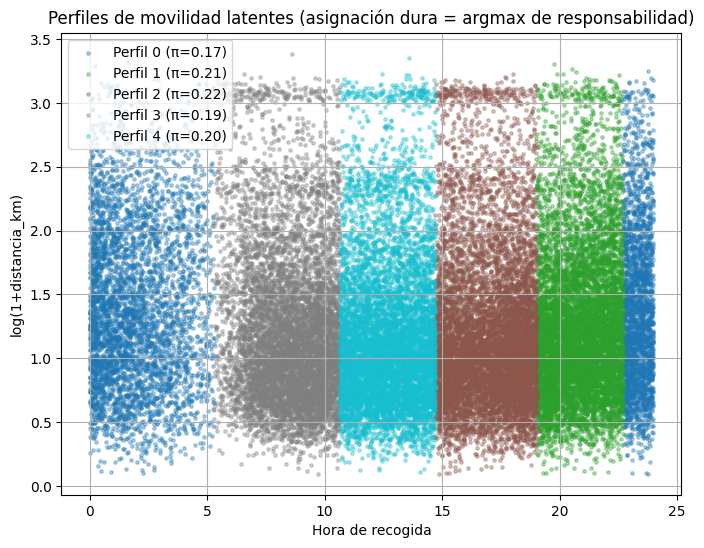

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, K))
for k in range(K):
    mask = hard_assignment == k
    ax.scatter(df.loc[mask, "hour"], df.loc[mask, "log_distance"],
               s=6, alpha=0.35, color=colors[k], label=f"Perfil {k} (π={weights_final[k]:.2f})")
ax.set_xlabel("Hora de recogida"); ax.set_ylabel("log(1+distancia_km)")
ax.set_title("Perfiles de movilidad latentes (asignación dura = argmax de responsabilidad)")
ax.legend()
plt.show()


## Responsabilidades como probabilidades de pertenencia (no asignación rígida)

El valor diferencial de un GMM frente a K-means es precisamente que **no fuerza una asignación dura**: cada viaje tiene una probabilidad de pertenecer a cada perfil. Un viaje "ambiguo" (por ejemplo, a las 7 a.m. de un sábado) puede tener responsabilidad repartida entre el perfil de "commuter" y el de "fin de semana" esa incertidumbre es información de negocio útil (ej.: UrbanMove no debería tratar esas zonas/horarios con reglas binarias rígidas).

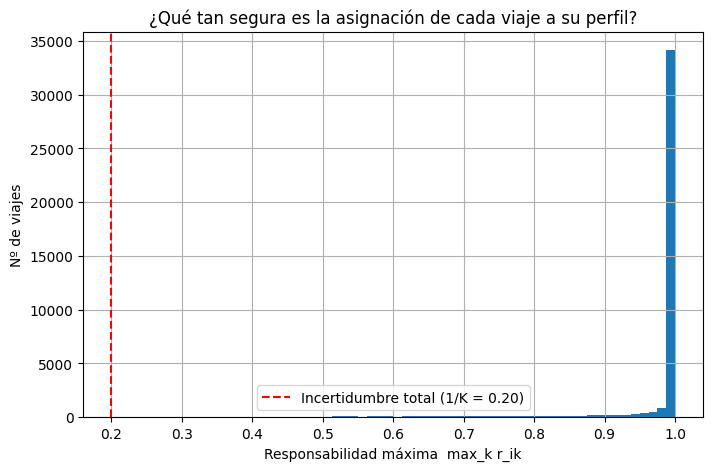

1.2% de los viajes tienen una responsabilidad máxima menor a 0.6 (es decir, el modelo no está seguro de a qué perfil pertenecen — viajes 'frontera').


In [42]:
# Distribución de la máxima responsabilidad: qué tan "seguro" está el modelo de cada asignación
max_resp = resp_final.max(axis=1)

plt.hist(max_resp, bins=40)
plt.axvline(1/K, color="red", linestyle="--", label=f"Incertidumbre total (1/K = {1/K:.2f})")
plt.xlabel("Responsabilidad máxima  max_k r_ik"); plt.ylabel("Nº de viajes")
plt.title("¿Qué tan segura es la asignación de cada viaje a su perfil?")
plt.legend(); plt.show()

pct_ambiguos = (max_resp < 0.6).mean() * 100
print(f"{pct_ambiguos:.1f}% de los viajes tienen una responsabilidad máxima menor a 0.6 "
      f"(es decir, el modelo no está seguro de a qué perfil pertenecen — viajes 'frontera').")


In [43]:
# Ejemplos concretos de viajes ambiguos (útiles para citar en la defensa oral)
idx_ambiguos = np.argsort(max_resp)[:5]
cols_show = ["hour", "trip_duration", "distance_km", "speed_kmh", "is_weekend"]
resp_df = pd.DataFrame(resp_final, columns=[f"P(perfil={k})" for k in range(K)])

pd.concat([df.iloc[idx_ambiguos][cols_show].reset_index(drop=True),
           resp_df.iloc[idx_ambiguos].round(3).reset_index(drop=True)], axis=1)


,hour,trip_duration,distance_km,speed_kmh,is_weekend,P(perfil=0),P(perfil=1),P(perfil=2),P(perfil=3),P(perfil=4)
0,19.000000,443,1.818838,14.780621,0,0.000,0.500,0.500,0.0,0.0
1,22.716667,1643,3.443985,7.546164,0,0.499,0.501,0.000,0.0,0.0
2,19.000000,713,2.332821,11.778617,0,0.000,0.499,0.501,0.0,0.0
3,19.016667,1248,2.640610,7.617143,0,0.000,0.499,0.501,0.0,0.0
4,19.000000,974,3.698520,13.670094,1,0.000,0.502,0.498,0.0,0.0


## Exportar métricas 

In [44]:
profile_table.round(3).to_csv("rol3_perfiles_latentes.csv", index=False)
summary_init.to_csv("rol3_comparacion_inicializaciones.csv", index=False)

with open("rol3_resumen_convergencia.txt", "w", encoding="utf-8") as f:
    f.write("ROL 3 - RESUMEN PARA EL DOCUMENTO PDF DEL EQUIPO\n")
    f.write("="*55 + "\n")
    f.write(f"K (numero de perfiles, seleccionado por BIC): {K}\n")
    f.write(f"Variables de entrada al GMM: {FEATURES}\n")
    f.write(f"Tamano de muestra utilizado: {len(X)} viajes\n\n")
    f.write("Inicializacion K-means++:\n")
    f.write(f"  Log-likelihood final (mejor de {N_RUNS} corridas): {best_run['ll_history'][-1]:.2f}\n")
    f.write(f"  Iteraciones hasta convergencia: {best_run['n_iter']}\n")
    f.write(f"  Media +/- std log-likelihood (10 semillas): "
            f"{summary_init.loc[summary_init.init=='kmeans++','final_log_likelihood'].mean():.2f} +/- "
            f"{summary_init.loc[summary_init.init=='kmeans++','final_log_likelihood'].std():.2f}\n\n")
    f.write("Inicializacion aleatoria:\n")
    f.write(f"  Media +/- std log-likelihood (10 semillas): "
            f"{summary_init.loc[summary_init.init=='random','final_log_likelihood'].mean():.2f} +/- "
            f"{summary_init.loc[summary_init.init=='random','final_log_likelihood'].std():.2f}\n\n")
    f.write(f"Log-likelihood sklearn GaussianMixture (validacion): {ll_sklearn_total:.2f}\n")
    f.write(f"Porcentaje de viajes con asignacion ambigua (max responsabilidad < 0.6): {pct_ambiguos:.1f}%\n")

print("Archivos exportados:")
print(" - rol3_perfiles_latentes.csv")
print(" - rol3_comparacion_inicializaciones.csv")
print(" - rol3_resumen_convergencia.txt")


Archivos exportados:
 - rol3_perfiles_latentes.csv
 - rol3_comparacion_inicializaciones.csv
 - rol3_resumen_convergencia.txt


## Estratega de Negocio y Selección de Datos

### Justificación de la selección y estructuración de datos

El equipo trabajó sobre una **muestra aleatoria reproducible de 40 000 viajes** (`random_state=42`) del total de ~1.4M registros del dataset NYC Taxi Trip Duration. Este tamaño es estadísticamente suficiente para estimar distribuciones de probabilidad estables (entropía, KL, información mutua) sin el costo computacional de procesar el archivo completo en cada iteración.

Antes de cualquier análisis se aplicó un proceso de limpieza que descartó registros no plausibles:

| Filtro | Regla | Registros afectados |
|---|---|---|
| Coordenadas fuera de NYC | lat ∈ [40.5, 40.9], lon ∈ [-74.05, -73.7] | — |
| `passenger_count = 0` | excluido | — |
| `trip_duration` extremo | 60s – 4h | — |
| Duplicados exactos | excluidos | — |
| **Total limpieza inicial** | | 40 000 → **39 541** (1.1% eliminado) |
| Filtro adicional de plausibilidad física (velocidad, distancia) para el GMM | 1–100 km/h, 0.1–60 km | 39 541 → **39 305** (0.6% eliminado) |

Esta doble limpieza no es un atajo técnico: sin ella, la entropía por zona se infla artificialmente por "zonas fantasma" con coordenadas erróneas, y el GMM produce covarianzas mal condicionadas por velocidades imposibles.

### Integración de los tres bloques técnicos

**Rol 1 (Información e incertidumbre):**
- La demanda es más predecible entre las 2 y 4 a.m. (entropía 2.94–2.99 bits) y más dispersa entre 5 y 6 a.m. (3.41–3.43 bits).
- En horario pico la demanda está ligeramente más concentrada que en valle (3.139 vs 3.183 bits).
- La hora del día por sí sola solo reduce un 2.1% la incertidumbre sobre la zona (I=0.067 bits) — es una señal débil que debe combinarse con otra variable.
- Día laboral vs. fin de semana son distribuciones parecidas (D_KL=0.0358 bits): no se justifica una estrategia de flota completamente distinta entre semana y fin de semana.
- La media geométrica de duración (10.8 min) es un mejor estimador del viaje típico que la media aritmética (14.0 min), inflada por pocos viajes muy largos (desigualdad de Jensen).

**Rol 2 (Segmentación por partición):**
- K-means y clustering jerárquico coinciden en **K=2** (silueta=0.436, Davies-Bouldin=0.899): un segmento de alto volumen/viaje corto (717 viajes prom., 14.8 min, 4.3 km, zona central) y otro de bajo volumen/viaje largo (166 viajes prom., 43.4 min, 14.6 km, zona periférica).
- DBSCAN detectó **1 zona atípica** (zona `2_6`, solo 4 viajes) que no encaja densamente en ningún segmento.

**Rol 3 (Mezclas y variables latentes) — actualizado:**
- El GMM ahora se ajusta con **K=5** (elegido con la mejora marginal del BIC, ya que el BIC puro seguía bajando hasta K=15 sin estabilizarse — señal de sobreajuste si se usa el mínimo puro).
- Los 5 perfiles de movilidad, con pesos entre 17% y 22%, tienen etiquetas de negocio claras: commuter matutino (π=0.20, 8:35 a.m.), movilidad nocturna de semana (π=0.21, 8:58 p.m.), madrugada/ocio nocturno (π=0.17, 1:01 a.m., mayor distancia y velocidad, 45% fin de semana), mediodía comercial (π=0.21, 12:56 p.m., menor velocidad por congestión) y retorno de tarde (π=0.22, 5:13 p.m., el de mayor volumen).
- Solo el **1.2%** de los viajes tiene asignación ambigua (responsabilidad máxima < 0.6), concentrados alrededor de las 7–11 p.m., en la frontera entre el perfil de retorno de tarde y el de movilidad nocturna.
- La inicialización K-means++ no solo converge más rápido (41.8 vs 60.9 iteraciones en promedio) sino que es **drásticamente más estable**: desviación estándar del log-likelihood final de 338.43 frente a 5 550.05 con inicialización aleatoria, que además cayó en un mínimo local severo en su peor semilla (-149 041 vs. -131 490 del mejor caso).

### Recomendaciones operativas para UrbanMove

**1. Reposicionamiento de conductores por ventana horaria de predictibilidad.**
Concentrar flota en las zonas de mayor demanda histórica durante la franja 2–4 a.m. (entropía mínima, 2.94–2.99 bits: la demanda cae en pocas zonas de forma consistente), y mantener flota flexible entre 5–6 a.m., donde la entropía sube a 3.41–3.43 bits y la ubicación de la próxima recogida es la más incierta del día.

**2. Tarificación diferenciada por segmento de zona (no por hora aislada).**
Dado que la hora sola explica poco (I=0.067 bits, 2.1%), usar el segmento K-means de la zona como variable primaria de precio: tarifa base estándar para el clúster de alto volumen/viaje corto (4.3 km, 14.8 min), y una tarifa con incentivo al conductor para el clúster de bajo volumen/viaje largo (14.6 km, 43.4 min, típico de trayectos periféricos).

**3. Asignación de flota diferenciada por perfil de movilidad (GMM, K=5).**
El perfil de retorno de tarde (π=0.22, 5:13 p.m., velocidad más baja por congestión) es el de mayor volumen: preposicionar la mayor parte de la flota disponible antes de las 5 p.m. El perfil de madrugada/ocio (π=0.17, 1:01 a.m., mayor distancia y velocidad, 45% fin de semana) permite a un conductor completar más viajes por hora pese a la distancia mayor, por lo que puede sostenerse sin tarifa de incentivo. Para el 1.2% de viajes "frontera" entre el perfil de retorno de tarde y el de movilidad nocturna (concentrados 7–11 p.m.), no forzar una categoría de despacho rígida: usar un pool combinado de conductores en esa franja horaria.

**4. Uso de inicialización K-means++ como política operativa del modelo.**
Dado que la inicialización aleatoria mostró una desviación estándar del log-likelihood 16 veces mayor que K-means++ (5 550.05 vs 338.43) y llegó a un mínimo local severo en su peor semilla, UrbanMove debe fijar K-means++ como inicialización estándar en cualquier reentrenamiento periódico del modelo. Esto evita que las recomendaciones de flota cambien de forma errática solo por una mala convergencia al reentrenar con datos nuevos.

**5. Tratamiento operativo de la zona atípica y de las métricas de tiempo reportadas.**
La zona de ruido detectada por DBSCAN (`2_6`, 4 viajes) se excluye de la definición de arquetipos pero se monitorea en próximos cortes como posible zona emergente. Adicionalmente, UrbanMove debe fijar sus SLA de tiempo de viaje esperado sobre la **media geométrica (10.8 min)**, no la media aritmética (14.0 min), para no sobreestimar sistemáticamente el tiempo real que experimenta el pasajero mediano.

### Limitaciones y siguientes pasos
El grid de zonas (10×10) es una simplificación geográfica; un siguiente corte debería usar zonas oficiales de NYC (community districts/taxi zones) para recomendaciones más accionables. El criterio de "mejora marginal del BIC" para elegir K=5 es una decisión razonable pero no única; conviene documentar en el reporte por qué se prefirió sobre el mínimo puro (K=15), que habría producido un modelo sobreajustado y difícil de interpretar operativamente. La ausencia de una diferencia fuerte laboral/fin de semana (D_KL=0.0358) sugiere explorar variables adicionales (clima, eventos) antes de descartar del todo una segmentación temporal más fina.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=73279afc-91cd-4aa8-8b25-1348e74727f1' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>